This tutorial demonstrates how to convert between a **Seurat** object in R and an **AnnData** object in Python.

Instead of relying on specialized conversion packages, we adopt a simple and transparent approach: writing all key components of the object (expression matrices, metadata, and embeddings) to a structured data directory, and then loading them back from that directory in the other environment.

In [1]:
%load_ext autoreload
%autoreload 2
%load_ext rpy2.ipython

### R to python

#### Step 1: (In R) Export Seurat object to a directory

Download the script [seu_dir_conversion.R](../scripts/seu_dir_conversion.R), then run the function export_seurat_to_anndata_dir() in R to write your Seurat object and its associated data to a structured output directory. 

In [ ]:
%%R
library(Seurat)
source("seu_dir_conversion.R") # Source the R script you downloaded
data(pbmc_small)  # Loads the Seurat object pbmc_small
export_seurat_to_anndata_dir(pbmc_small, "./data", "pbmc_small_test") # Exports the Seurat object to a directory named "pbmc_small_test" in the "data" folder

#### Step 2: (In Python) Load the exported data into an AnnData object

Run the following code to import the Seurat-exported directory and create an AnnData object in Python.

In [ ]:
import concord as ccd 
adata = ccd.ul.load_anndata_from_dir('./data/pbmc_small_test') # Note: you need CONCORD >= v1.0.10 to run this code
adata

AnnData object with n_obs × n_vars = 80 × 230
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.8', 'letter.idents', 'groups', 'RNA_snn_res.1'
    var: 'gene_names'
    obsm: 'X_tsne', 'X_pca'
    layers: 'counts'

Optionally run CONCORD in python:

In [3]:
# Run concord
cur_ccd = ccd.Concord(adata=adata, preload_dense=True) # Specify domain_key if integrating batches
cur_ccd.fit_transform(output_key='Concord')

concord - WARNING - No input feature list provided. It is recommended to first select features using the command `concord.ul.select_features()`.
concord - WARNING - domain/batch information not found, all samples will be treated as from single domain/batch.
concord - WARNING - Only one domain found in the data. Setting p_intra_domain to 1.0.


Epoch 0 Training
Epoch 1 Training
Epoch 2 Training
Epoch 3 Training
Epoch 4 Training
Epoch 5 Training
Epoch 6 Training
Epoch 7 Training
Epoch 8 Training
Epoch 9 Training
Epoch 10 Training
Epoch 11 Training
Epoch 12 Training
Epoch 13 Training
Epoch 14 Training


Compute and visualize CONCORD UMAP:

/opt/anaconda3/envs/concord/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


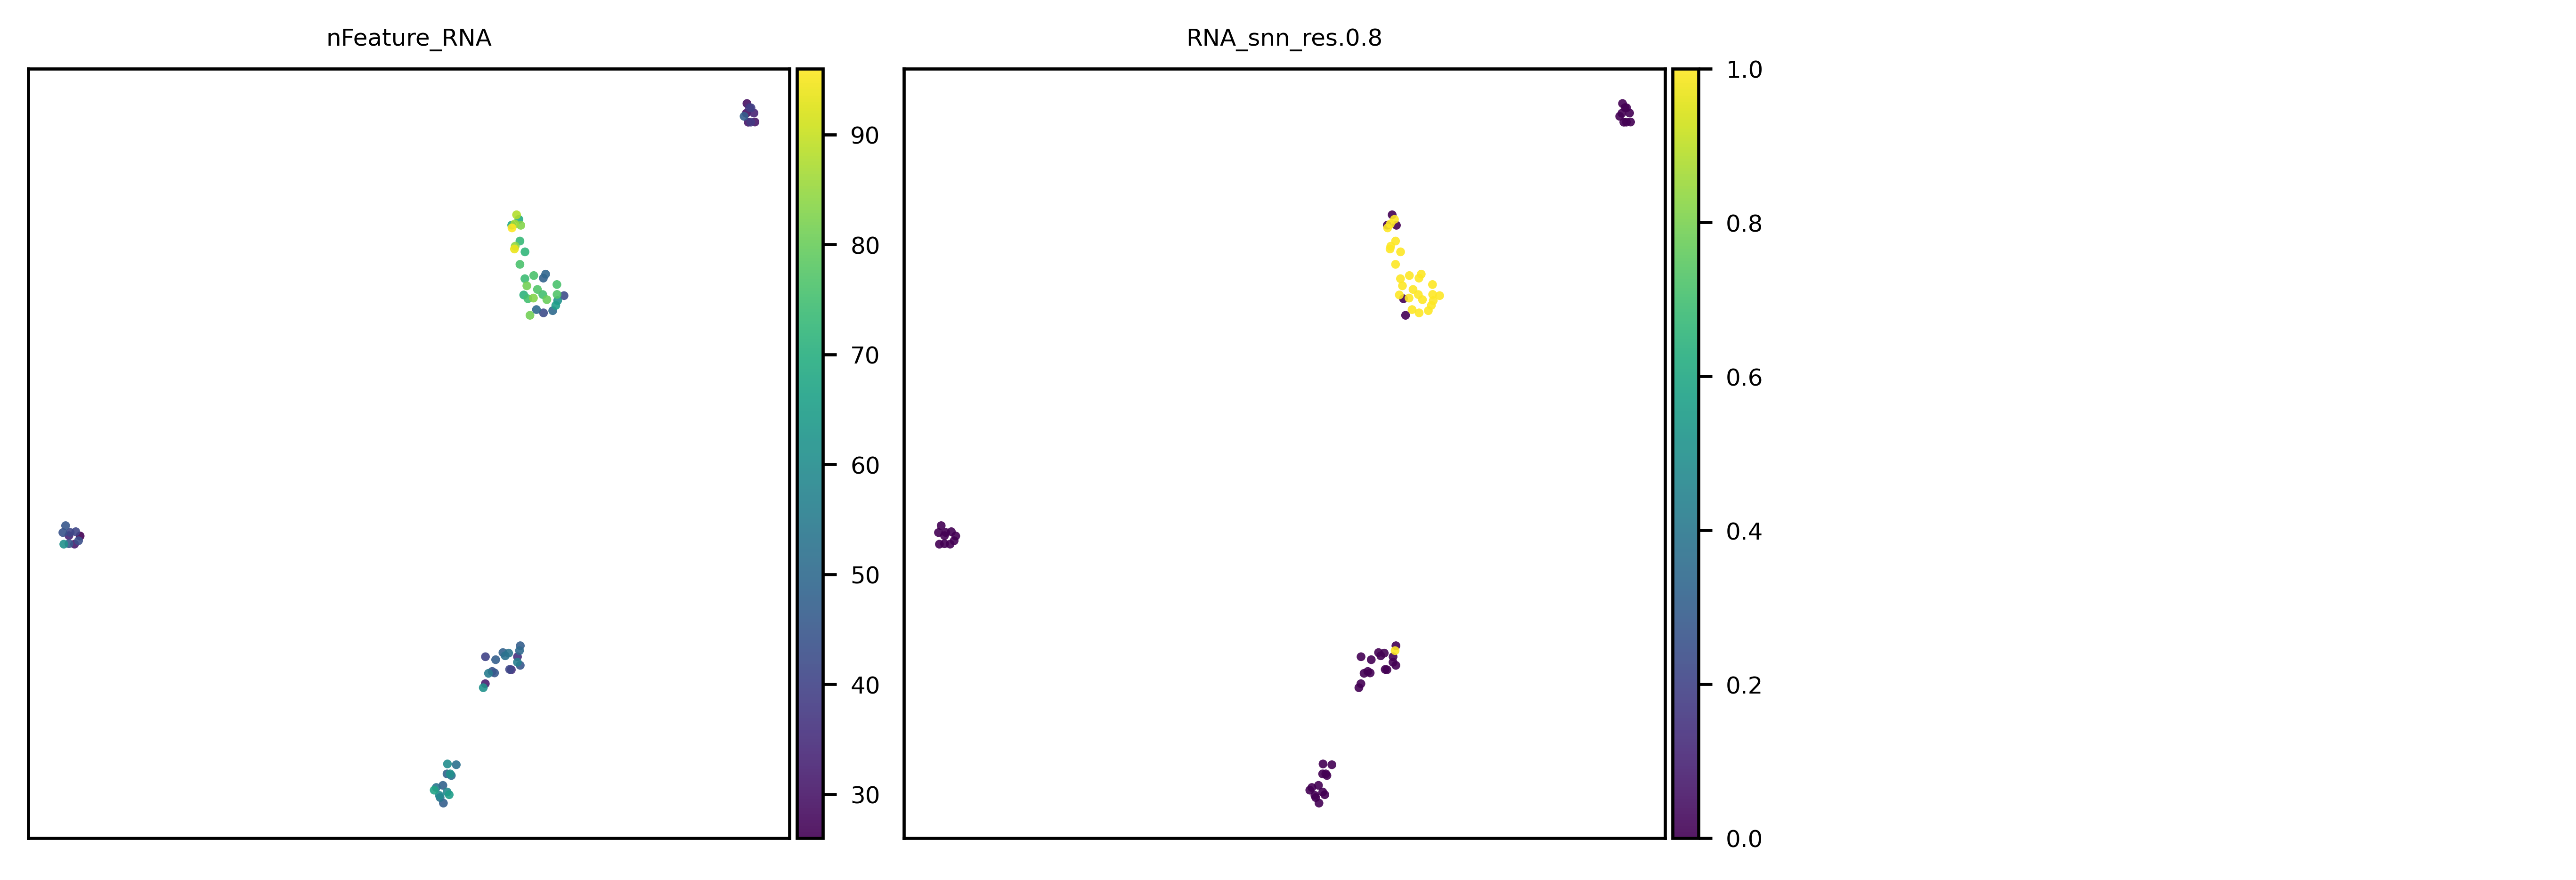

In [4]:
ccd.ul.run_umap(adata, source_key='Concord', result_key='Concord_UMAP', n_components=2, n_neighbors=30, min_dist=0.1, metric='cosine')
# Convert clustering results to string type for better visualization
adata.obs['RNA_snn_res.1'] = adata.obs['RNA_snn_res.1'].astype(str)
# Plot the UMAP embeddings
color_by = ['nFeature_RNA', 'RNA_snn_res.0.8'] # Choose which variables you want to visualize
ccd.pl.plot_embedding(
    adata, basis='Concord_UMAP', color_by=color_by, figsize=(9, 3), dpi=600, ncols=3, font_size=6, point_size=20, legend_loc='on data',
    save_path='Concord_UMAP.png'
)

### Python to R

#### Step 1: (In Python) Export Anndata object to a directory

In [ ]:
# export to directory to be loaded in R
ccd.ul.export_anndata_to_dir(adata, "./data/pbmc_small_test_wt_concord") # Note: you need CONCORD >= v1.0.10 to run this code

#### Step 2: (In R) Load the exported data into an Seurat object 

In [6]:
%%R
library(Seurat)
source("seu_dir_conversion.R")
seu_res = import_seurat_from_dir("./data/pbmc_small_test_wt_concord/")
seu_res



    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    An object of class Seurat 
230 features across 80 samples within 1 assay 
Active assay: RNA (230 features, 0 variable features)
 2 layers present: counts, data
 4 dimensional reductions calculated: Concord_UMAP, Concord, pca, tsne


Loading required package: SeuratObject
Loading required package: sp
‘SeuratObject’ was built under R 4.4.1 but the current version is
4.4.2; it is recomended that you reinstall ‘SeuratObject’ as the ABI
for R may have changed

Attaching package: ‘SeuratObject’

The following objects are masked from ‘package:base’:

    intersect, t

